In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df_hourly= pd.read_csv("../data/Processed/Solar_hourly_2021-2024.csv")

In [3]:
df_hourly["measured_on"]=pd.to_datetime(df_hourly["measured_on"])
df_hourly.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 16496 entries, 0 to 16495
Data columns (total 35 columns):
 #   Column              Non-Null Count  Dtype              
---  ------              --------------  -----              
 0   measured_on         16496 non-null  datetime64[ns, UTC]
 1   Power               16496 non-null  float64            
 2   Solar Zenith Angle  16496 non-null  float64            
 3   Aerosol_depth       16496 non-null  float64            
 4   Humidity            16496 non-null  float64            
 5   Surface Albedo      16496 non-null  float64            
 6   Wind Speed          16496 non-null  float64            
 7   Cloud Type          16496 non-null  float64            
 8   Pressure            16496 non-null  float64            
 9   Precipitable Water  16496 non-null  float64            
 10  Ozone               16496 non-null  float64            
 11  Temp                16496 non-null  float64            
 12  TotalCloudCover     16496 non-nu

In [4]:
unique_months = df_hourly['month'].unique() # to ensure that validation set has data from unseen months in training set

In [5]:
#eXtreme Gradient Boost

from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import r2_score
from sklearn.model_selection import KFold
import shap



rmse_scores = [0]*5
r2_scores= [0]*5

cols = ['Temp', 'DeltaT(0-1)',  'DeltaT(0-3)', 'Power_factor_inv1', 'Power_factor_inv2', 'Cloud Type', 'TotalCloudCover', 'Humidity', 'Zenith', 'Precipitation','day_of_year','Snowfall']
kf = KFold(n_splits=5, shuffle=True)
for i , (train_day_idx, test_day_idx) in enumerate(kf.split(unique_months)):
    train_days = unique_months[train_day_idx]
    test_days = unique_months[test_day_idx]
    train = df_hourly[df_hourly['month'].isin(train_days)]
    val= df_hourly[df_hourly['month'].isin(test_days)]
    train_X = train[cols]
    val_X = val[cols]
    train_y=train["Power"]
    val_y=val["Power"]
    
    
    from xgboost import XGBRegressor
    
    xgb_gb = XGBRegressor(
    enable_categorical=True,
    n_estimators=800,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=2.0,            
    reg_alpha=1.0,        
    reg_lambda=2.0,       
    random_state=42,
    early_stopping_rounds=25
)
    xgb_gb.fit(train_X, train_y, eval_set=[(val_X, val_y)], verbose=False)
    xgb_gb_pred=xgb_gb.predict(val_X)
    
    
    rmse_scores[i]=root_mean_squared_error(val_y,xgb_gb_pred)
    r2_scores[i]=r2_score(val_y,xgb_gb_pred)
    





print(f'RMSEs on each fold: \n {np.round(rmse_scores,2)}')
print(f'Mean RMSE: {np.round(np.mean(rmse_scores, axis = 0),2)}')
print(f'Standard deviation: {np.round(np.std(rmse_scores, axis = 0),2)}')
print(f'r2 on each fold: \n {np.round(r2_scores,2)}')
print(f'Mean r2: {np.round(np.mean(r2_scores, axis = 0),2)}')


RMSEs on each fold: 
 [528.1  525.62 587.37 563.08 519.6 ]
Mean RMSE: 544.75
Standard deviation: 26.18
r2 on each fold: 
 [0.85 0.85 0.79 0.81 0.85]
Mean r2: 0.83


/var/folders/f4/xfd055z54dzc8gv8yp56gc7h0000gn/T/ipykernel_34016/1546926204.py:43: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(Energy.index, Energy['Pred_Energy'], label= 'Predicted Energy')


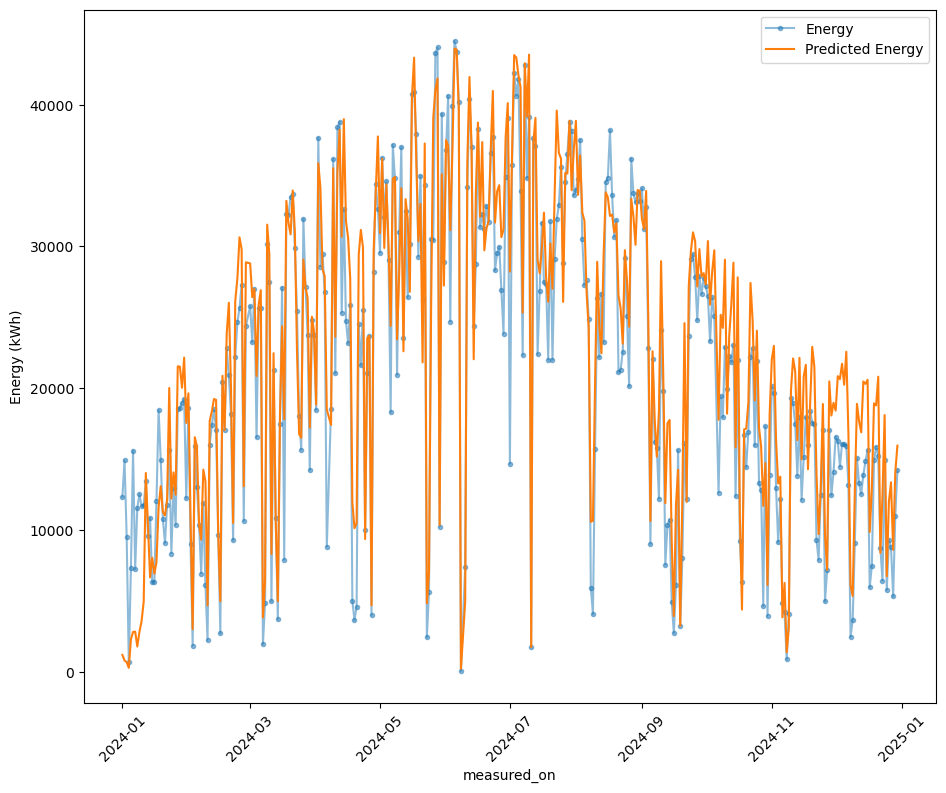

In [6]:

start_date = '2021-01-01'
end_date = '2023-12-31'
mask = (df_hourly['measured_on'] >= start_date) & (df_hourly['measured_on'] <= end_date)

train=df_hourly[mask]
mask_val=(df_hourly['measured_on'] >= '2024-01-01') & (df_hourly['measured_on'] <= '2024-12-31')
val=df_hourly[mask_val]

train = train.set_index('measured_on')
val = val.set_index('measured_on')

cols = [ 'Temp', 'DeltaT(2-0)',  'DeltaT(0-3)', 'Power_factor_inv1', 'Power_factor_inv2', 'Cloud Type', 'TotalCloudCover', 'Humidity', 'Zenith', 'Precipitation','day_of_year','Snowfall']
train_X = train[cols]
val_X = val[cols]
train_y=train["Power"]
val_y=val["Power"]


xgb_gb = XGBRegressor(
    enable_categorical=True,
    n_estimators=800,
    learning_rate=0.01,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=2.0,            
    reg_alpha=1.0,        
    reg_lambda=2.0,       
    random_state=42
)
xgb_gb.fit(train_X, train_y, verbose=False)

xgb_gb_pred=xgb_gb.predict(val_X)

val['date'] = val.index.date
val['Pred_Energy'] = xgb_gb_pred
Energy = val.groupby('date')[['Power', 'Pred_Energy']].sum()
Energy = Energy.rename(columns={'Power': 'Energy'})



axes= Energy['Energy'].plot(marker='.', alpha=0.5, figsize=(11, 9), label='Energy')
plt.plot(Energy.index, Energy['Pred_Energy'], label= 'Predicted Energy')

plt.xticks(rotation=45)    
plt.xlabel('measured_on')
plt.ylabel('Energy (kWh)')
plt.legend()
plt.show()
#Energy.head(5)

In [7]:
#XGB Random Forest 


for i , (train_day_idx, test_day_idx) in enumerate(kf.split(unique_months)):
    train_days = unique_months[train_day_idx]
    test_days = unique_months[test_day_idx]
    train = df_hourly[df_hourly['month'].isin(train_days)]
    val= df_hourly[df_hourly['month'].isin(test_days)]
    train_X = train[cols]
    val_X = val[cols]
    train_y=train["Power"]
    val_y=val["Power"]
    
    
    from xgboost import XGBRFRegressor
    
    xgb_rf = XGBRFRegressor(n_estimators=800,max_depth=6,subsample=0.8, colsample_bynode=0.8, 
                            enable_categorical=True, 
                            gamma=1.0, reg_alpha=2.0, reg_lambda=2.5)
    xgb_rf.fit(train_X, train_y)

    xgb_rf_pred=xgb_rf.predict(val_X)
    
    rmse_scores[i]=root_mean_squared_error(val_y,xgb_rf_pred)
    r2_scores[i]=r2_score(val_y,xgb_rf_pred)
    





print(f'RMSEs on each fold: \n {np.round(rmse_scores,2)}')
print(f'Mean RMSE: {np.round(np.mean(rmse_scores, axis = 0),2)}')
print(f'Standard deviation: {np.round(np.std(rmse_scores, axis = 0),2)}')
print(f'r2 on each fold: \n {np.round(r2_scores,2)}')
print(f'Mean r2: {np.round(np.mean(r2_scores, axis = 0),2)}')

RMSEs on each fold: 
 [682.69 652.5  586.95 683.6  690.03]
Mean RMSE: 659.15
Standard deviation: 38.37
r2 on each fold: 
 [0.72 0.79 0.7  0.74 0.77]
Mean r2: 0.74


/var/folders/f4/xfd055z54dzc8gv8yp56gc7h0000gn/T/ipykernel_34016/3624493540.py:34: UserWarning: This axis already has a converter set and is updating to a potentially incompatible converter
  plt.plot(Energy.index, Energy['Pred_Energy'], label= 'Predicted Energy')


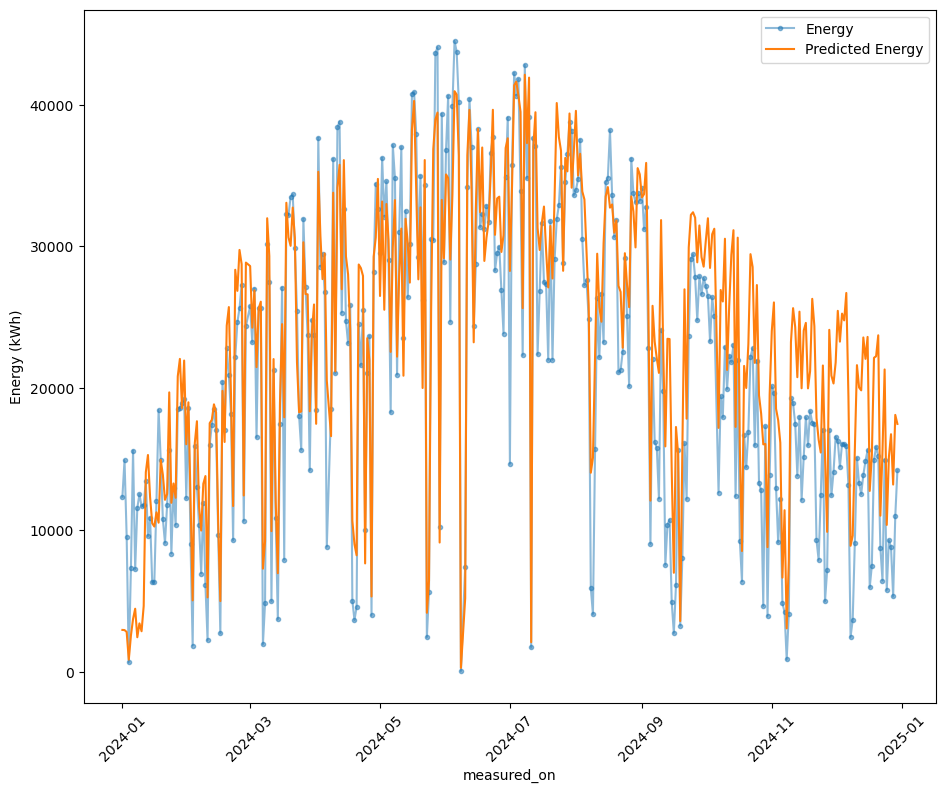

In [8]:
start_date = '2021-01-01'
end_date = '2023-12-31'
mask = (df_hourly['measured_on'] >= start_date) & (df_hourly['measured_on'] <= end_date)

train=df_hourly[mask]
mask_val=(df_hourly['measured_on'] >= '2024-01-01') & (df_hourly['measured_on'] <= '2024-12-31')
val=df_hourly[mask_val]

train = train.set_index('measured_on')
val = val.set_index('measured_on')

cols = [ 'Temp', 'DeltaT(2-0)',  'DeltaT(0-3)', 'Power_factor_inv1', 'Power_factor_inv2', 'Cloud Type', 'TotalCloudCover', 'Humidity', 'Zenith', 'Precipitation','day_of_year','Snowfall']
train_X = train[cols]
val_X = val[cols]
train_y=train["Power"]
val_y=val["Power"]


xgb_rf = XGBRFRegressor(n_estimators=500,max_depth=6,subsample=0.8, colsample_bynode=0.8, 
                            enable_categorical=True, 
                            gamma=1.0, reg_alpha=2.0, reg_lambda=2.5)
xgb_rf.fit(train_X, train_y)

xgb_rf_pred=xgb_rf.predict(val_X)

val['date'] = val.index.date
val['Pred_Energy'] = xgb_rf_pred
Energy = val.groupby('date')[['Power', 'Pred_Energy']].sum()
Energy = Energy.rename(columns={'Power': 'Energy'})



axes= Energy['Energy'].plot(marker='.', alpha=0.5, figsize=(11, 9), label='Energy')
plt.plot(Energy.index, Energy['Pred_Energy'], label= 'Predicted Energy')

plt.xticks(rotation=45)    
plt.xlabel('measured_on')
plt.ylabel('Energy (kWh)')
plt.legend()
plt.show()
#Energy.head(5)

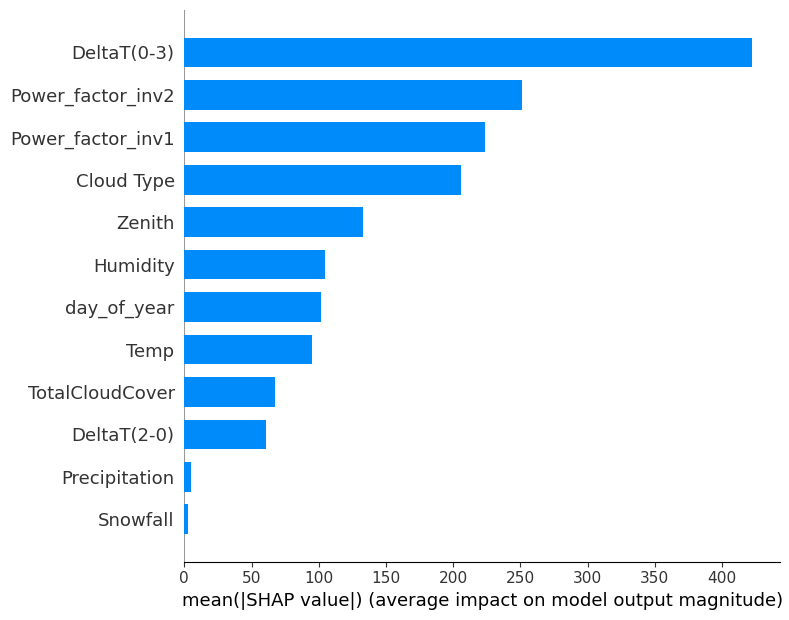

In [9]:
import shap
explainer = shap.TreeExplainer(xgb_gb)
shap_values = explainer.shap_values(val_X)
shap.summary_plot(shap_values, val_X, plot_type="bar")

<Axes: title={'center': 'Feature importance'}, xlabel='F score', ylabel='Features'>

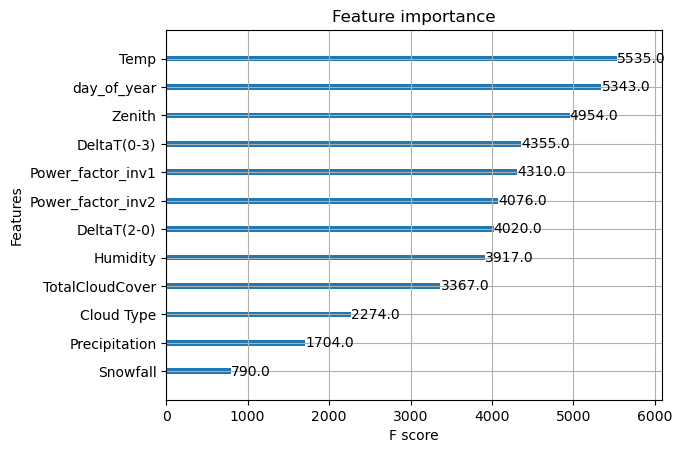

In [10]:
import xgboost
xgboost.plot_importance(xgb_gb)

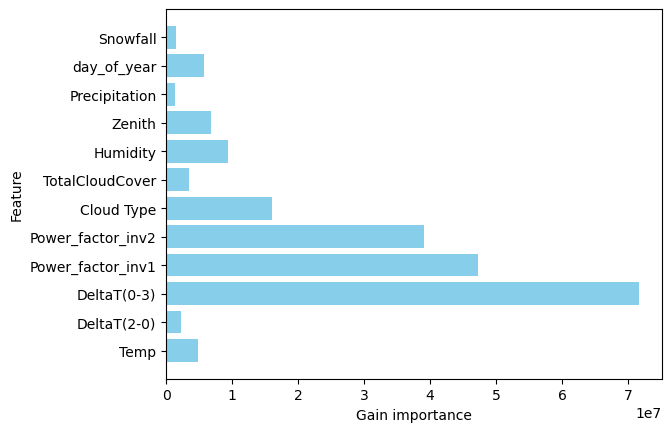

In [11]:
gain_importance = xgb_gb.get_booster().get_score(importance_type='gain')
labels = list(gain_importance.keys())
values = list(gain_importance.values())
plt.barh(labels, values, color='skyblue')
plt.xlabel("Gain importance")
plt.ylabel("Feature")
plt.show()